In [11]:
import pandas as pd
import numpy as np

cols = ["contig", "pos", "motif", "read_id", "pred_label", "prob"]

wt = pd.read_csv("/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastWT.NNANN.tsv",sep="\t", header=None, names=cols)
ko = pd.read_csv("/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastKO.NNANN.tsv",sep="\t", header=None, names=cols)

wt["pos"]  = wt["pos"].astype(int)
ko["pos"]  = ko["pos"].astype(int)
wt["prob"] = wt["prob"].astype(float)
ko["prob"] = ko["prob"].astype(float)

In [12]:
def site_level(df, prob_th=0.5, cov_th=3):
    df = df.copy()
    df["is_mod"] = (df["prob"] >= prob_th).astype(int)
    g = df.groupby(["contig", "pos", "motif"], as_index=False)
    site = g.agg(
        n_reads   = ("prob", "size"),
        mean_prob = ("prob", "mean"),
        std_prob  = ("prob", "std"),
        meth_rate = ("is_mod", "mean"),
    )
    site = site[site["n_reads"] >= cov_th]
    return site
wt_site = site_level(wt, prob_th=0.9, cov_th=10)
ko_site = site_level(ko, prob_th=0.9, cov_th=10)


In [13]:
print("WT sites:", len(wt_site))
print("KO sites:", len(ko_site))
print("Common sites:", len(pd.merge(wt_site, ko_site, on=["contig", "pos", "motif"])))

WT sites: 430487
KO sites: 456538
Common sites: 306428


In [14]:
merged = wt_site.merge(
    ko_site,
    on=["contig", "pos", "motif"],
    how="outer",
    suffixes=("_wt", "_ko")
).fillna(0)

merged["delta_meth"] = merged["meth_rate_wt"] - merged["meth_rate_ko"]
merged["delta_prob"] = merged["mean_prob_wt"] - merged["mean_prob_ko"]


In [15]:
hc = merged[
    (merged["n_reads_wt"] >= 15) &
    (merged["n_reads_ko"] >= 15) &
    (merged["meth_rate_wt"] >= 0.3) &
    (merged["meth_rate_ko"] <= 0.1) &
    (merged["delta_meth"] >= 0.4)
].copy()

print("High-confidence m6A sites in IME4-dependent manner:", len(hc))
out_path = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9D_Yeast_IME4_dep_m6A_sites.tsv"
hc.to_csv(out_path, sep="\t", index=False)
print("Saved to:", out_path)

hc.head()

High-confidence m6A sites in IME4-dependent manner: 523
Saved to: /mnt/sunxh/sunxh/wattmamba/new_result/supfig9D_Yeast_IME4_dep_m6A_sites.tsv


,contig,pos,motif,n_reads_wt,mean_prob_wt,std_prob_wt,meth_rate_wt,n_reads_ko,mean_prob_ko,std_prob_ko,meth_rate_ko,delta_meth,delta_prob
682,chr1,66977,ATACA,16.0,0.746168,0.228357,0.5,32.0,0.283362,0.266090,0.000000,0.500000,0.462806
1735,chr1,133364,TTAGT,16.0,0.500754,0.466453,0.5,56.0,0.262954,0.276417,0.071429,0.428571,0.237800
3237,chr1,194149,ATAAT,16.0,0.480273,0.486011,0.5,36.0,0.111067,0.196563,0.000000,0.500000,0.369206
3238,chr1,194150,TAATA,16.0,0.494943,0.472626,0.5,36.0,0.107223,0.261140,0.000000,0.500000,0.387719
4147,chr1,212726,ATATT,16.0,0.636906,0.345231,0.5,28.0,0.139607,0.162458,0.000000,0.500000,0.497299


In [16]:
import numpy as np

delta = merged["meth_rate_wt"] - merged["meth_rate_ko"]

print("delta mean:", delta.mean())
print("delta percentiles:", np.percentile(delta, [5, 25, 50, 75, 95]))

up   = (delta >  0.2).sum()
down = (delta < -0.2).sum()
print("WT much higher than KO:", up)
print("KO much higher than WT:", down)
print("WT of hc sites:", hc["meth_rate_wt"].describe())
print("KO of hc sites:", hc["meth_rate_ko"].describe())



delta mean: 0.002525329695720832
delta percentiles: [-0.11111111  0.          0.          0.          0.14285714]
WT much higher than KO: 17103
KO much higher than WT: 14045
WT of hc sites: count    523.000000
mean       0.473256
std        0.089148
min        0.400000
25%        0.400000
50%        0.500000
75%        0.500000
max        0.857143
Name: meth_rate_wt, dtype: float64
KO of hc sites: count    523.000000
mean       0.004132
std        0.017825
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.100000
Name: meth_rate_ko, dtype: float64


In [17]:
hc["motif"] = hc["motif"].astype(str)

def is_drach(m: str) -> bool:
    """DRACH motif, 这里用 DNA 字母：D=A/G/T, R=A/G, H=A/C/T"""
    m = m.upper()
    if len(m) != 5:
        return False
    b1, b2, b3, b4, b5 = m
    if b3 != "A":
        return False
    if b4 != "C":
        return False
    if b1 not in "AGT":  # D
        return False
    if b2 not in "AG":   # R
        return False
    if b5 not in "ACT":  # H
        return False
    return True

def is_rrach(m: str) -> bool:
    """RRACH motif, [A/G][A/G]AC[ACT]"""
    m = m.upper()
    if len(m) != 5:
        return False
    b1, b2, b3, b4, b5 = m
    if b3 != "A" or b4 != "C":
        return False
    if b1 not in "AG":
        return False
    if b2 not in "AG":
        return False
    if b5 not in "ACT":
        return False
    return True

hc_drach = hc[hc["motif"].apply(is_drach)].copy()
hc_rrach = hc[hc["motif"].apply(is_rrach)].copy()

print("All hc sites:", len(hc))
print("DRACH hc sites:", len(hc_drach))
print("RRACH hc sites:", len(hc_rrach))

print("\nWT meth (DRACH hc):")
print(hc_drach["meth_rate_wt"].describe())
print("\nKO meth (DRACH hc):")
print(hc_drach["meth_rate_ko"].describe())


All hc sites: 523
DRACH hc sites: 84
RRACH hc sites: 73

WT meth (DRACH hc):
count    84.000000
mean      0.490145
std       0.095382
min       0.400000
25%       0.400000
50%       0.500000
75%       0.500000
max       0.833333
Name: meth_rate_wt, dtype: float64

KO meth (DRACH hc):
count    84.000000
mean      0.007867
std       0.024079
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.100000
Name: meth_rate_ko, dtype: float64


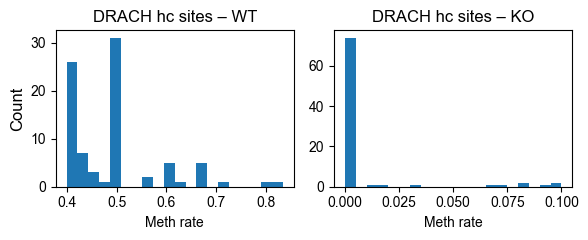

In [18]:
import matplotlib.pyplot as plt
import matplotlib
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

matplotlib.rcParams["font.family"] = "Arial"

axes[0].hist(hc_drach["meth_rate_wt"], bins=20)
axes[0].set_xlabel("Meth rate", fontsize=10)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("DRACH hc sites – WT", fontsize=12)
axes[0].tick_params(axis='both', labelsize=10)

axes[1].hist(hc_drach["meth_rate_ko"], bins=20)
axes[1].set_xlabel("Meth rate", fontsize=10)
axes[1].set_ylabel("", fontsize=12)
axes[1].set_title("DRACH hc sites – KO", fontsize=12)
axes[1].tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9D_Yeast_meth_rate.pdf", dpi=1200, bbox_inches="tight")
plt.show()


chr2:372552 GGACA – WT reads: 24, KO reads: 120
chr12:939742 AGACA – WT reads: 20, KO reads: 24
chr16:170286 GGACT – WT reads: 24, KO reads: 24
chr8:406504 GGACA – WT reads: 24, KO reads: 36
chr11:450534 AGACA – WT reads: 24, KO reads: 36
chr3:38649 GGACT – WT reads: 24, KO reads: 24
chr3:275229 GGACA – WT reads: 100, KO reads: 176
chr4:410593 GGACA – WT reads: 32, KO reads: 24
chr12:687702 GAACT – WT reads: 20, KO reads: 28


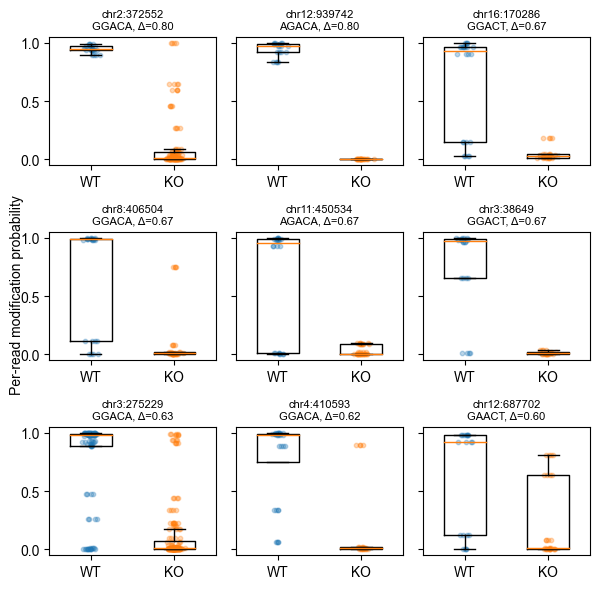

In [19]:
import numpy as np
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Arial"

wt["pos"] = wt["pos"].astype(int)
ko["pos"] = ko["pos"].astype(int)
matplotlib.rcParams["font.family"] = "Arial"
top_sites = hc_drach.sort_values("delta_meth", ascending=False)

top_plot = 10
sites_to_plot = top_sites.head(top_plot).reset_index(drop=True)

rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows), sharey=True)
axes = axes.flatten()
fig.text(0.02, 0.5, "Per-read modification probability",
         va="center", ha="center", rotation="vertical")
for i, row in sites_to_plot.iterrows():
    if i >= rows * cols:
        break

    ax = axes[i]
    contig = row["contig"]
    pos    = int(row["pos"])
    motif  = row["motif"]
    delta  = row["delta_meth"]

    mask_wt = (wt["contig"] == contig) & (wt["pos"] == pos) & (wt["motif"] == motif)
    mask_ko = (ko["contig"] == contig) & (ko["pos"] == pos) & (ko["motif"] == motif)

    wt_probs = wt.loc[mask_wt, "prob"].astype(float).values
    ko_probs = ko.loc[mask_ko, "prob"].astype(float).values 

    print(f"{contig}:{pos} {motif} – WT reads: {len(wt_probs)}, KO reads: {len(ko_probs)}")
    ax.boxplot(
        [wt_probs, ko_probs],
        positions=[0, 1],
        widths=0.5,
        showfliers=False
    )

    x_wt = np.random.normal(0, 0.04, size=len(wt_probs))
    x_ko = np.random.normal(1, 0.04, size=len(ko_probs))
    ax.scatter(x_wt, wt_probs, alpha=0.3,s=10)
    ax.scatter(x_ko, ko_probs, alpha=0.3,s=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["WT", "KO"])
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{contig}:{pos}\n{motif}, Δ={delta:.2f}")

for j in range(len(sites_to_plot), rows*cols):
    fig.delaxes(axes[j])
plt.rcParams["axes.titlesize"] = 8
out_csv = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9E_Yeast_per-read_modification_sites.tsv"
sites_to_plot.to_csv(out_csv, sep="\t", index=False)
plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9E_Yeast_per-read_modification.pdf", dpi=1200, bbox_inches="tight")
plt.show()


In [20]:
import pandas as pd
import numpy as np

merged["motif"] = merged["motif"].astype(str)
merged["pos"]   = merged["pos"].astype(int)

def is_nnann(m: str) -> bool:
    m = m.upper()
    return (len(m) == 5) and (m[2] == "A")

nnann = merged[merged["motif"].apply(is_nnann)].copy()

nnann = nnann[
    (nnann["meth_rate_wt"] >= 0.3) &
    (nnann["meth_rate_ko"] <= 0.1) &
    (nnann["n_reads_wt"]   >= 10) &
    (nnann["n_reads_ko"]   >= 5)
].copy()

nnann = nnann.sort_values(["contig", "pos"])

print("Selected NNANN sites (WT>0.3, KO<0.1):", len(nnann))
nnann.head()

Selected NNANN sites (WT>0.3, KO<0.1): 4497


,contig,pos,motif,n_reads_wt,mean_prob_wt,std_prob_wt,meth_rate_wt,n_reads_ko,mean_prob_ko,std_prob_ko,meth_rate_ko,delta_meth,delta_prob
15,chr1,41617,CTAGT,20.0,0.478979,0.387025,0.400000,64.0,0.393082,0.322283,0.062500,0.337500,0.085897
137,chr1,50759,CAAGA,12.0,0.334361,0.489249,0.333333,24.0,0.011541,0.024804,0.000000,0.333333,0.322820
186,chr1,50928,ATAAC,12.0,0.399057,0.410314,0.333333,44.0,0.133255,0.147751,0.000000,0.333333,0.265802
187,chr1,50929,TAACG,12.0,0.469985,0.362072,0.333333,44.0,0.232170,0.343005,0.090909,0.242424,0.237815
517,chr1,60671,TAATG,12.0,0.458525,0.346371,0.333333,28.0,0.244600,0.247903,0.000000,0.333333,0.213925


In [21]:
nnann["dist_prev"] = nnann.groupby("contig")["pos"].diff()
distances = nnann["dist_prev"].dropna()

print("Total distances:", len(distances))
print(distances.describe())
contig_info = []
grouped = nnann.groupby("contig")["pos"]

for contig, pos_series in grouped:
    pos_sorted = np.sort(pos_series.values)
    n = len(pos_sorted)
    if n < 2:
        continue
    contig_info.append({
        "contig": contig,
        "n": n,
        "min_pos": pos_sorted.min(),
        "max_pos": pos_sorted.max()
    })

len(contig_info)

Total distances: 4480
count     4480.000000
mean      2510.860938
std       6139.564204
min          1.000000
25%          6.000000
50%         45.000000
75%       1163.000000
max      63574.000000
Name: dist_prev, dtype: float64


16

Null distances: 8960
Raw distances saved to: /mnt/sunxh/sunxh/wattmamba/new_result/Yeast_NNANN_distance_raw.csv


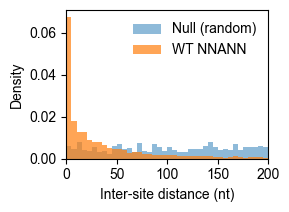

In [22]:
rng = np.random.default_rng(22)
n_perm = 2

null_distances = []
matplotlib.rcParams["font.family"] = "Arial"

for _ in range(n_perm):
    for info in contig_info:
        n = info["n"]
        if n < 2:
            continue
        L_min = info["min_pos"]
        L_max = info["max_pos"]

        rand_pos = rng.integers(L_min, L_max + 1, size=n)
        rand_pos.sort()

        d = np.diff(rand_pos)
        null_distances.append(d)

null_distances = np.concatenate(null_distances)
print("Null distances:", len(null_distances))
import matplotlib.pyplot as plt
import pandas as pd

out_csv_raw = "/mnt/sunxh/sunxh/wattmamba/new_result/Yeast_NNANN_distance_raw.csv"

df_raw = pd.DataFrame({
    "distance": np.concatenate([distances, null_distances]),
    "type": (["WT"] * len(distances)) + (["Null"] * len(null_distances))
})

df_raw.to_csv(out_csv_raw, sep=",", index=False)
print("Raw distances saved to:", out_csv_raw)

max_dist = 200
bins = np.arange(0, max_dist + 5, 5)

fig, ax = plt.subplots(figsize=(3,2.22))

ax.hist(null_distances, bins=bins, alpha=0.5,
        label="Null (random)", density=True)
ax.hist(distances,      bins=bins, alpha=0.7,
        label="WT NNANN", density=True)

ax.set_xlim(0, max_dist)
ax.set_xlabel("Inter-site distance (nt)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfigG_Yeast_Distance.pdf"
plt.savefig(
    out_pdf,
    format="pdf",
    dpi=1200,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker
import pandas as pd
import numpy as np

cols = ["contig", "pos", "motif", "read_id", "pred_label", "prob"]

wt = pd.read_csv("/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastWT.NNANN.tsv",sep="\t", header=None, names=cols)
ko = pd.read_csv("/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastKO.NNANN.tsv",sep="\t", header=None, names=cols)

wt["pos"]  = wt["pos"].astype(int)
ko["pos"]  = ko["pos"].astype(int)
wt["prob"] = wt["prob"].astype(float)
ko["prob"] = ko["prob"].astype(float)


In [24]:
th = 0.9

wt_mod_reads = wt[wt["prob"] >= th].copy()
ko_mod_reads = ko[ko["prob"] >= th].copy()

print("WT 修饰 read 数:", len(wt_mod_reads))
print("KO 修饰 read 数:", len(ko_mod_reads))

wt_motifs = [m.upper() for m in wt_mod_reads["motif"].astype(str) if len(m) == 5]
ko_motifs = [m.upper() for m in ko_mod_reads["motif"].astype(str) if len(m) == 5]

print("WT 5-mer 数:", len(wt_motifs))
print("KO 5-mer 数:", len(ko_motifs))


WT 修饰 read 数: 577608
KO 修饰 read 数: 470628
WT 5-mer 数: 577608
KO 5-mer 数: 470628


In [25]:
import pandas as pd

merged["motif"] = merged["motif"].astype(str)

cov_wt_th = 30
cov_ko_th = 10

wt_sites = merged[
    (merged["meth_rate_wt"] >= 0.4) &
    (merged["meth_rate_ko"] <= 0.2) &
    (merged["n_reads_wt"]   >= cov_wt_th) &
    (merged["n_reads_ko"]   >= cov_ko_th)
].copy()

ko_sites = merged[
    (merged["meth_rate_ko"] >= 0.3) &
    (merged["meth_rate_wt"] <= 0.1) &
    (merged["n_reads_wt"]   >= cov_wt_th) &
    (merged["n_reads_ko"]   >= cov_ko_th)
].copy()

wt_motifs = [m for m in wt_sites["motif"].astype(str) if len(m) == 5]
ko_motifs = [m for m in ko_sites["motif"].astype(str) if len(m) == 5]

print("WT-high sites:", len(wt_sites), "motifs:", len(wt_motifs))
print("KO-high sites:", len(ko_sites), "motifs:", len(ko_motifs))

import logomaker
import matplotlib.pyplot as plt


WT-high sites: 91 motifs: 91
KO-high sites: 497 motifs: 497


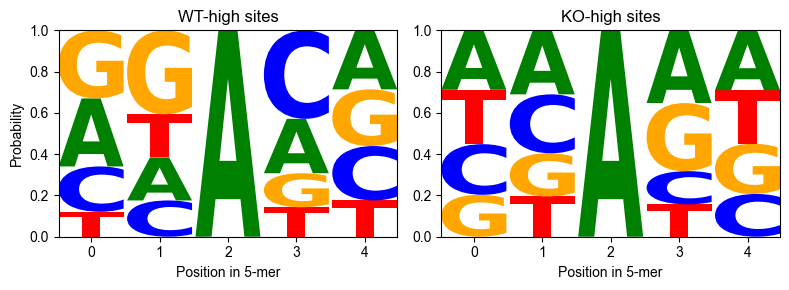

In [ ]:
import numpy as np
matplotlib.rcParams["font.family"] = "Arial"

def motifs_to_probs(motifs):
    motifs = [m for m in motifs if isinstance(m, str) and len(m) == 5]
    if len(motifs) == 0:
        return None
    counts = logomaker.alignment_to_matrix(motifs, to_type="counts")
    probs = counts.div(counts.sum(axis=1), axis=0)
    return probs
wt_counts = motifs_to_probs(wt_motifs)
ko_counts = motifs_to_probs(ko_motifs)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes[0]
if wt_counts is not None:
    logomaker.Logo(wt_counts, ax=ax)
    ax.set_title(f"WT-high sites", fontsize=12)
    ax.set_xlabel("Position in 5-mer")
    ax.set_ylabel("Probability")

ax = axes[1]
if ko_counts is not None:
    logomaker.Logo(ko_counts, ax=ax)
    ax.set_title(f"KO-high sites", fontsize=12)
    ax.set_xlabel("Position in 5-mer")
    ax.set_ylabel("")
out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfigF_Yeast_WT_KO_motif_logo.pdf"
plt.tight_layout()
plt.savefig(
    out_pdf,
    format="pdf",     
    dpi=1200,         
    bbox_inches="tight"
)
plt.show()
